Part 1: Parsing the dataset

In [1]:
import os.path
import tarfile
from urllib.request import urlretrieve

url = "http://www.cs.cornell.edu/people/pabo/movie-review-data/review_polarity.tar.gz"
if not os.path.exists(url.split("/")[-1]):
    urlretrieve(url, url.split("/")[-1])
    print("Downloaded", url)
    with tarfile.open('review_polarity.tar.gz', 'r:gz') as tar:
        tar.extractall()
    print("Extracted archive")

In [2]:
import os

def load_moive_review_dataset(data_dir):
    X_raw = []
    y =[]

    #positive reviews
    pos_dir = os.path.join(data_dir, "pos")
    for filename in os.listdir(pos_dir):
        filepath = os.path.join(pos_dir, filename)
        with open (filepath, "r", encoding = "latin-1") as f:
            X_raw.append(f.read())
            y.append(1)
    
    #negative reivews
    neg_dir = os.path.join(data_dir, "neg")
    for filename in os.listdir(neg_dir):
        filepath = os.path.join(neg_dir, filename)
        with open(filepath, "r", encoding = "latin-1") as f:
            X_raw.append(f.read())
            y.append(-1)

    return X_raw, y

X_raw, y = load_moive_review_dataset("txt_sentoken")

In [3]:
import numpy as np
y = np.array(y) #transformed into numpy array
# assert len(X_text) == 2000
assert np.all([isinstance(x, str) for x in X_raw])
assert len(X_raw) == y.shape[0]
assert len(np.unique(y))==2
assert y.min() == -1
assert y.max() == 1

In [5]:
#VG part
#K-fold 
#1.shuffle the data
indices = np.random.permutation(len(y))
X_shuffled = [X_raw[i] for i in indices]
y_shuffled = [y[i] for i in indices]

#2.k-fold set
k = 5
fold_size = len(X_shuffled) //k

fold_acuracies_bow = []
fold_val_accuracies_bow = []
fold_acuracies_tfidf = []
fold_val_accuracies_tfidf = []

for i in range(k):
    start = i*fold_size
    end = (i+1) * fold_size
    #split fold
    X_val = X_shuffled[start:end]
    y_val = y_shuffled[start:end]
    X_train = X_shuffled[:start] + X_shuffled[end:]
    y_train = y_shuffled[:start] + y_shuffled[end:]

    #3.convert labels to -1/1
    y_train = np.array(y_train)
    y_train[y_train == 0] = -1
    y_val = np.array(y_val)
    y_val[y_val == 0] = -1

#4.check the data
print("Number of training samples:", len(X_train))
print("Number of test samples:", len(X_val))
print("unique labels in y_train:", np.unique(y_train))
print("unique lables in y_val:", np.unique(y_val))

Number of training samples: 1600
Number of test samples: 400
unique labels in y_train: [-1  1]
unique lables in y_val: [-1  1]


Part 2: Feature extraction

In [6]:
from collections import defaultdict
import numpy as np
#define function to retrieve ordered_vocabulary
#the reason to do this part is to do the same process for both of training data and test data separately

#define vectorizer class
class vectorizer:
    #X as input dataset
    def __init__(self, X_train):
        self.X_train = X_train #the training data
        self.n_of_doc = len(X_train) #the number of documents, the 1st dimention of X 
        self.ordered_vocabulary = []#to be used in get_vocabulary() method
        self.dict_for_bow = {} #defaultdict to be used in get_bow_for_sentence() method
        self.tf = None
        self.idf = None
        
    def get_vocabulary(self):
        #in the for loop, split each sentence into word leve, and if the word doesn't exit in ordered_vocabulary, append it to the list
        #caculate the document frequency
        vocab_set = set()
        tf_counter = defaultdict(int)

        for sentence in self.X_train :
            words = set(sentence.split())
            vocab_set.update(words)
            for w in words:
                tf_counter[w] += 1
            
        self.ordered_vocabulary = list(vocab_set)
        self.dict_for_bow = {
            w: i for i,w in enumerate(self.ordered_vocabulary)
        }

        #standard TF-IDF
        self.tf = np.array([tf_counter[w] for w in self.ordered_vocabulary])
        self.idf = np.log((self.n_of_doc +1)/(self.tf +1))
        return self.ordered_vocabulary
    
    #define method: get_bow_for_sentence to retrieve bug of words information of each sentence
    def get_bow_for_sentence(self,X):
        #create 2 dimentional numpy array with 0:[#of documents, #of unique words]
        n_samples = len(X)
        n_features = len(self.ordered_vocabulary)
        bow_for_sentence = np.zeros((n_samples, n_features))
        #add key-value(word: in the index number in order_vocabulary list)
        #the purpose to use dictionary is to avoid nested for loop x if conditions

        for i, sentence in enumerate(X):
            words = sentence.split()
            #in the for loop, create the list of 0 with the length of ordered_vocabulary, and split sentence into word level:
            for word in words:
                if word in self.dict_for_bow:
                    idx = self.dict_for_bow[word]
                    bow_for_sentence[i, idx] += 1 #TF: term frequency
        return bow_for_sentence
    
    def get_tfidf_for_sentece(self,X):
        tf = self.get_bow_for_sentence(X)
        tfidf = tf * self.idf
        return tfidf
    
vec = vectorizer(X_train)
vocab = vec.get_vocabulary()
ordered_vocabulary = vocab
vocabulary = ordered_vocabulary
print("Vocabulary size:", len(vocab))

#BOW
X_train_vec_bow = vec.get_bow_for_sentence(X_train)
X_val_vec_bow = vec.get_bow_for_sentence(X_val)

#TFIDF
X_train_tfidf = vec.get_tfidf_for_sentece(X_train)
X_val_tfidf = vec.get_tfidf_for_sentece(X_val)
X_raw_tfidf = vec.get_tfidf_for_sentece(X_raw)

print("X_train_vec_bow shape:", X_train_vec_bow.shape)
print("X_val_vec_bow shape:", X_val_vec_bow.shape)

print("X_train_vec_tfidf shape:", X_train_tfidf.shape)
print("X_val_vec_tfidf shape:", X_val_tfidf.shape)



Vocabulary size: 45469
X_train_vec_bow shape: (1600, 45469)
X_val_vec_bow shape: (400, 45469)
X_train_vec_tfidf shape: (1600, 45469)
X_val_vec_tfidf shape: (400, 45469)


In [7]:
#g part
class G_HyperplaneClassifier:
    def __init__(self, learning_rate=0.01, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter

    def fit(self, X, y):
        import numpy as np
        
        n_samples, n_features = X.shape
        
        # 初始化權重（+1 for bias）
        self.w = np.zeros(n_features + 1)

        # 加 bias term
        X_bias = np.hstack([np.ones((n_samples, 1)), X])

        for _ in range(self.max_iter):
            gradient = np.zeros_like(self.w)

            # 🔥 Batch GD：一次用全部資料
            for i in range(n_samples):
                xi = X_bias[i]
                yi = y[i]

                # hinge loss gradient（SVM-style）
                if yi * np.dot(self.w, xi) < 1:
                    gradient += -yi * xi

            # 平均 gradient
            gradient /= n_samples

            # 更新
            self.w -= self.learning_rate * gradient

    def predict(self, X):
        import numpy as np
        
        n_samples = X.shape[0]
        X_bias = np.hstack([np.ones((n_samples, 1)), X])
        
        scores = np.dot(X_bias, self.w)
        return np.sign(scores)

    def score(self, X, y):
        import numpy as np
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [10]:
# 假設 X_raw, y 已經有了

split = int(0.8 * len(X_raw))

X_train_raw = X_raw[:split]
X_test_raw = X_raw[split:]

y_train = y[:split]
y_test = y[split:]

In [12]:
# Vectorizer
vectorizer = BoWVectorizer()
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

# Model
model = G_HyperplaneClassifier(learning_rate=0.01, max_iter=1000)
model.fit(X_train, y_train)

# Evaluation
print("Training accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Training accuracy: 0.83125
Test accuracy: 0.915


In [13]:
y_pred = model.predict(X_test)
print(set(y_pred))

{np.float64(1.0), np.float64(-1.0)}


Part 3: Learning framework

In [ ]:
#hyperplane model
class HyperplaneClassifier:
    """
    A hyperplane classifier using hinge loss with L1 regularization.
    Implements SGD and momentum for optimization.
    """

    def __init__(self, learning_rate = 0.01, reg_param = 0.01, max_iter= 1000,tol = 1e-4,batch_size=32,random_state = None):
        self.learning_rate = learning_rate 
        self.reg_param = reg_param #regularization parameter(λ) for L1 regularization
        self.max_iter = max_iter
        self.tol = tol #tolerance for stopping critertion
        self.batch_size = batch_size
        self.random_state = random_state #random seed for reproducibility
        self.w = None #parameter vector
        self.loss_history = [] #track loss over iterations
        self.momentum = 0.9
        self.velocity = None

    def _add_pseudo_input(self, X):
        """
        Add pseudo input(bias term) as the first column.
        Parameters:
        X: array-like, shape(n_samples, n_features)
        Training data

        Return:
        X_pseudo : (n_samples, n_features +1)
        """
    
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])
    
    def _hyperplane_model(self, X,w):
        """
        hyperplane model : h(x) = sign(w^T x)
        X: data with pseudo input
        w:parameter vector

        return:
        predicitons: predicted labels{-1,1}
        """
        return np.sign(X@w)
    
    def _hinge_loss(self, X, y, w):
        """
        compute hinge loss: L(w) = (1/N) * Σ max(0,1-y_i * w^T X_i)
        X: data with pseudo input
        y: true labels {-1,1}
        w: parameter vector

        retunrs:
        loss: float(hinge loss value)
        """
        margins = y *(X @ w)
        losses = np.maximum(0, 1 -margins)
        return np.mean(losses)
    
    def _l1_norm(self, w):
        """
        compute hinge loss: L(w) = Σ |q_i|
        w: parameter vector

        returns
        norm: float
                L1 norm value
        """
        return np.sum(np.abs(w))
    
    def _objective_function(self, X, y, w):
        """
        compute objective function: J(w) = L(w) + λ * ||w||_1
        X:data with pseudo input
        y:true labels {-1,1}
        w: parameter vector

        return:
        objective:float
                objective function value
        """
        hinge = self._hinge_loss(X, y, w)
        regularization = self.reg_param * self._l1_norm(w)
        return hinge + regularization
    
    def _compute_gradient(self, X, y,w):
        """
        compute gradient: ∇J(w) = -(1/N) * Σ I[y_i * w^T x_i <1] * y_i *x_i + λ*sign(w)

        return:
        gradient: gradient vector
        """
        n_samples = X.shape[0]

        #compute margins : y_i * w^T x_i
        margins = y * (X@w)

        #indicator function:I[y_i * w^T x_i <1]
        indicators = (margins <1).astype(float)

        #gradient from hinge loss:-(1/N) * ΣI[...]* y_i*x_i
        hinge_gradient = -(1/n_samples) *(X.T @(indicators * y))

        #gradient from L1 regularization: λ * sign(w)
        reg_gradient = self.reg_param * np.sign(w)

        #total gradient 
        return hinge_gradient + reg_gradient
    def fit(self, X,y, verbose = False):
        """
        fit the hyperplane classifier using SGD and momentum
        verbose: bool, whether to print progress

        return:
        self: object
        """
        #initialize momentum SGD
        self.velocity = np.zeros_like(self.w)

        #convert to numpy arrays
        X = np.array(X)
        y = np.array(y)

        #add pseudo input
        X_pseudo = self._add_pseudo_input(X)
        n_features = X_pseudo.shape[1]

        #initialize parameters
        if self.random_state is not None:
            np.random.seed(self.random_state)
        self.w = np.random.randn(n_features) * 0.01

        #track previous w for convergence check
        w_prev = self.w.copy()

        convergence_count = 0

        #SGD
        for iteration in range(self.max_iter):
           #step 1:shuffle data     
            indices = np.random.permutation(len(X_pseudo))
            X_shuffled = X_pseudo[indices]
            y_shuffled = y[indices]

            #step 2: mini-batch updates
            for start in range(0, len(X_pseudo), self.batch_size):
                X_batch = X_shuffled[start:start + self.batch_size]
                y_batch = y_shuffled[start:start + self.batch_size]

                gradient = self._compute_gradient(X_batch, y_batch, self.w)
                
                #momentum update
                self.velocity = self.momentum *self.velocity +self.learning_rate * gradient
                self.w = self.w - self.velocity
        
            #tracking/ convergence
            obj_value = self._objective_function(X_pseudo, y, self.w)
            self.loss_history.append(obj_value)

            #check convergence : ||w_t - w_{t-1}|| < tol
            diff = np.linalg.norm(self.w - w_prev)

            if diff < self.tol:
                convergence_count += 1
                if convergence_count >= 5:
                    if verbose:
                        print(f"Converged at iteration {iteration +1}")
                    break
            else:
                convergence_count = 0

            #update w_prev
            w_prev = self.w.copy()

            #print progress 
            if verbose and (iteration +1) % 100 == 0:
                print(f"Iteration {iteration+1}:Loss = {obj_value:.6f}, "
                    f"||w_t - w_{{t-1}}|| = {diff:.6f}")
                
        return self
    def predict(self,X):
        """
        Predict class labels for samples in X
        returns:
        y_pred: predicted class labels {-1, 1}
        """
        if self.w is None:
            raise ValueError("Model has not been fitted yet!")
        
        X = np.array(X)
        X_pseudo = self._add_pseudo_input(X)
        scores = X_pseudo @ self.w
        return np.sign(scores)

    def decision_function(self, X):
        """
        Compute the decision function (w^T x) for samples in X.
        X: test data
        return:
        score:decision function values
        """
        if self.w is None:
            raise ValueError("Model has not been fitted yet!")
        
        X = np.array(X)
        X_pseudo = self._add_pseudo_input(X)
        return X_pseudo @ self.w

    def score(self, X ,y):
        """
        compute the accuracy of predictions
        X: test data
        y:true labels
        returns: accuracy score
        """

        y_pred = self.predict(X)
        return np.mean(y_pred == y)

model_bow = HyperplaneClassifier(
    learning_rate=0.005,
    reg_param=0.01,
    max_iter=2000,
    tol = 1e-4,
    batch_size=32,
    random_state=42
)

#using BoW
model_bow.fit(X_train_vec_bow, y_train, verbose=False)
acc = model_bow.score(X_val_vec_bow, y_val)
fold_acuracies_bow.append(acc)
fold_val_accuracies_bow.append(model_bow.score(X_val_vec_bow,y_val))
print(model_bow.loss_history[:5])
print(model_bow.loss_history[-5:])
print("Training accuracy: %.1f%%" % (100*model_bow.score(X_train_vec_bow, y_train)))
print("Test accuracy: %.1f%%" % (100* model_bow.score(X_val_vec_bow, y_val)))
print("Mean train accuracy:%.1f%%" % np.mean(100*np.mean(fold_acuracies_bow)))
print("Mean validation accuracy:%.1f%%" % np.mean(100*np.mean(fold_val_accuracies_bow)))

[-1  1]
[-1  1]
[np.float64(1.8915759204905638), np.float64(3.8355361351752615), np.float64(1.2946824459542807), np.float64(2.849409193786797), np.float64(1.856285760781435)]
[np.float64(1.7891106919171254), np.float64(3.5646627890934948), np.float64(1.374375467969994), np.float64(1.5432481015526336), np.float64(1.3446188813472015)]
Training accuracy: 83.6%
Test accuracy: 76.5%
Mean train accuracy:76.5%
Mean validation accuracy:76.5%


In [10]:
#using tf-idf
model_tfidf = HyperplaneClassifier(
    learning_rate=0.005,
    reg_param=0.01,
    max_iter=2000,
    tol = 1e-4,
    batch_size=32,
    random_state=42
)
model_tfidf.fit(X_train_tfidf, y_train, verbose=False)

#using 5-fold
acc1 = model_tfidf.score(X_val_tfidf, y_val)
fold_acuracies_tfidf.append(acc1)
fold_val_accuracies_tfidf.append(model_tfidf.score(X_val_tfidf,y_val))

print(model_tfidf.loss_history[:5])
print(model_tfidf.loss_history[-5:])
print("Training accuracy: %.1f%%" % (100*model_tfidf.score(X_train_tfidf, y_train)))
print("Test accuracy: %.1f%%" % (100* model_tfidf.score(X_val_tfidf, y_val)))
print("Mean train accuracy:%.1f%%"% np.mean(100*np.mean(fold_acuracies_tfidf)))
print("Mean validation accuracy:%.1f%%" % np.mean(100*np.mean(fold_val_accuracies_tfidf)))


[np.float64(2.244842866944739), np.float64(1.3499983627206196), np.float64(1.3652129086020521), np.float64(1.5287504981216637), np.float64(1.2443412746437343)]
[np.float64(1.1883762847803774), np.float64(1.2534749613114564), np.float64(1.134564081533971), np.float64(1.2996703840703803), np.float64(1.3884969260295135)]
Training accuracy: 94.8%
Test accuracy: 81.8%
Mean train accuracy:81.8%
Mean validation accuracy:81.8%


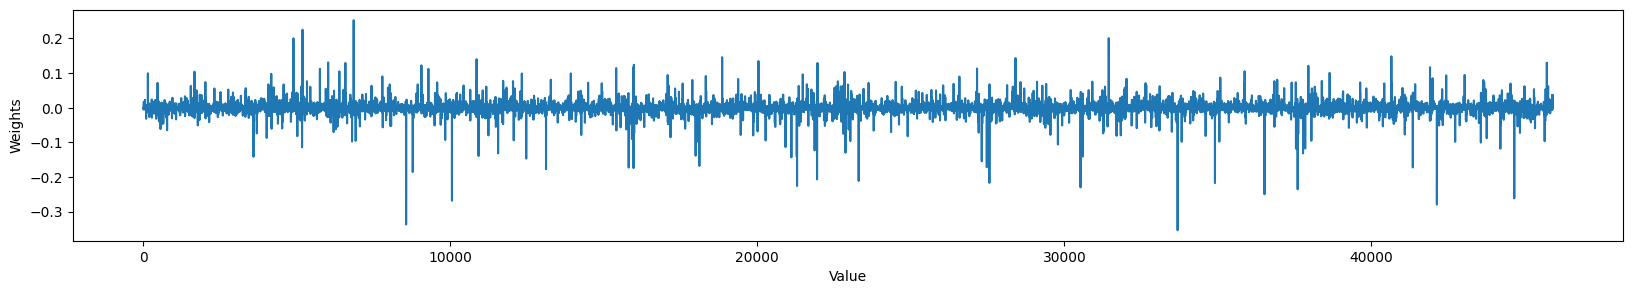

In [11]:
import matplotlib.pyplot as plt

omega = model_tfidf.w
plt.figure(figsize=(20, 3))
plt.plot(omega[1:])
plt.xlabel("Value")
plt.ylabel("Weights")
plt.show()

In [20]:
assert (len(omega)-1) == len(vocabulary)

# Sort by absolute value
idx = np.argsort(np.abs(omega[1:])) #absolute value from high to low
print("                Word   Weight  Occurences")
for i in idx[-20:]:
    word = ordered_vocabulary[i]
    weight = omega[i+1]
    tfidf_sum = X_raw_tfidf[:, i].sum()
    print(f"{word:25s}  {weight:.6f}\t{tfidf_sum:.3f}")

                Word   Weight  Occurences
lame                       -0.178315	322.803
terrific                   0.178672	356.566
plot                       -0.183999	1220.870
tired                      -0.189052	256.155
dull                       -0.194276	378.489
worst                      -0.197696	660.860
hilarious                  0.198087	476.561
seen                       0.200083	1067.948
great                      0.203457	1207.667
awful                      -0.206423	369.952
mess                       -0.214815	408.084
fun                        0.214975	861.894
waste                      -0.250826	392.343
ridiculous                 -0.271950	376.072
supposed                   -0.272970	673.018
nothing                    -0.273500	975.431
leila                      0.274930	193.872
unfortunately              -0.337856	670.168
bad                        -0.456276	1330.641
&nbsp                      -0.577034	387.744


Part 4: Exploring hyperparameters

In [17]:
import numpy as np

n_samples = 10
best_hyperparameters = None

print("Learning rate:\tReg.dampening:\tTraining set accuracy")

for learing_rate, reg_param in zip(
    np.random.choice(np.logspace(-4, 0, num = 1000), n_samples),
    np.random.choice(np.logspace(-4, 0, num=1000), n_samples)
):
    model = HyperplaneClassifier(
        learning_rate= learing_rate,
        reg_param=reg_param,
        max_iter=1000,
        tol=1e-4,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train, verbose=False)
    #calculate training accuracy
    training_accuracy = model.score(X_train_tfidf, y_train)

    #upate best hperparameters
    if best_hyperparameters is None or best_hyperparameters[2] < training_accuracy:
        best_hyperparameters = (learing_rate, reg_param, training_accuracy)
    
    print("%.5f\t%.5f\t%.1f%%" % (learing_rate, reg_param,100*training_accuracy))

best_learning_rate = best_hyperparameters[0]
best_reg_param = best_hyperparameters[1]
print("Best parameters: %.5f, %.5f" % (best_learning_rate,best_reg_param))



Learning rate:	Reg.dampening:	Training set accuracy
0.07497	0.02503	81.8%
0.00259	0.83931	54.0%
0.05530	0.00628	94.3%
0.00236	0.25084	67.3%
0.53918	0.09705	62.7%
0.00741	0.42036	58.5%
1.00000	0.00599	93.5%
0.08297	0.01439	87.9%
0.03968	0.22457	59.8%
0.00119	0.77964	54.4%
Best parameters: 0.05530, 0.00628


In [18]:
model = HyperplaneClassifier(learning_rate=best_learning_rate,
                             reg_param=best_reg_param,
                             max_iter=1000,
                             tol= 1e-4,
                             random_state=42)

model.fit(X_train_tfidf, y_train)

test_accuracy = model.score(X_val_tfidf, y_val)
print("Test set accuracy %.1f%%" % (100*test_accuracy))

Test set accuracy 80.8%


Part5: Analysis(G part)

The final model is a linear hyperplane classifier trained using batch gradient descent with hinge loss and L1 regularization. The decision boundary is a linear function in the high-dimensional bag-of-words space, where each word corresponds to one dimension. Words with large positive weights contribute to a positive sentiment prediction, while words with large negative weights push the decision towards a negative lable. Due to the use of L1 regularization, many weights are driven towards zero, resulting in a sparse model where only a subset of words has a strong influence on the decision.

Hyperparmeters such as the learning rate and regularization strength were selected using random sampling from logarithmically spaced grids. While the model achieves reasonable training accuracy, test performance is noticeably lower, indicating limited generalization. This can be attributed to the very high dimensional feature space and the use of batch gradient descent, which may converge to suboptimal solutions. Overall, the implementation demonstrates the core principles of linear classification and margin-based learning, but leaves room for improvement through alternative optimization strategies or feature representations.


Part 6: Reflection

This is my first machine learning assignment, and through this project I realized how important data preprocessing is. At one point, my test accuracy dropped to only 2%, which was very confusing. After carefully checking the data, I discoverd that my test set did not contain any negative samples. As a result, the evaluation was unreliable and misleading. Once I corrected the data splitting issue, the accuracy improved significantly. This experience made me understand that even a correct model cannot perform properly if the data pipeline is flawed.

I decided to work on the VG part mainly because my initial test accuracy was only 46%, and I wanted to improve the model performance. Instead of changing the modele entirely, I focused on refining the existing pipeline. For example, when switching from Bag-of-Words to TF-IDF, I observed that the learned weight became much more interpretable, with clearly identifiable positive and negative sentiment words. This demonstrated how feature representation can significantly impact performance.

I also found k-fold cross-validation particularly interesting. By rotating the validation set across different subsets of the training data, the evaluation became more stable and reliable. I would like to further deepen my understanding of cross-validation techniques, as they seem essential for proper model selection and evluation.